#  Projet de Fin de Module — Deep Learning
## EMSI Casablanca — Année universitaire 2025–2026



## 📋 Table des matières
- **Partie I** — MLP 
- **Partie II** — CNN + dérivés 
- **Partie III** — RNN / LSTM / GRU / Transformers 


---
# 🔵 PARTIE I — MLP  <a id='partie-i'></a>

**Thème :** Classification supervisée sur données tabulaires avec un perceptron multicouche (MLP).

**Dataset :** *Wine Quality* (sklearn) — 178 exemples, 13 features, 3 classes.

**Plan :**
1. Théorie
2. Préparation des données
3. MLP version `nn.Sequential`
4. MLP version classe personnalisée
5. Inspection des paramètres
6. Trois initialisations
7. Vérification device
8. Test de 5 architectures → sélection du Best Model
9. Évaluation complète du Best Model
10. Question de synthèse

---
##  Cellule 1 — Imports globaux

In [3]:
# ================================================================
# IMPORTS GLOBAUX
# ================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version : {torch.__version__}')
print(f'Device utilisé  : {device}')

PyTorch version : 2.11.0+cpu
Device utilisé  : cpu


---
##  Étape I.1 — Préparation des données

In [4]:
# ================================================================
# CHARGEMENT ET EXPLORATION
# ================================================================
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')

# Séparer features et cible
X_np = df.drop('quality', axis=1).values
y_np = df['quality'].values

# Transformer les notes (3-8) en classes (0,1,2,3,4,5)
le = LabelEncoder()
y_np = le.fit_transform(y_np)

print('=== Dataset Wine Quality UCI ===')
print(f'Exemples  : {X_np.shape[0]}')
print(f'Features  : {X_np.shape[1]}')
print(f'Classes   : {list(le.classes_)}')
print(f'Distribution :')
for i, classe in enumerate(le.classes_):
    print(f'  classe {i} (qualité {classe}) = {np.sum(y_np==i)} exemples')

=== Dataset Wine Quality UCI ===
Exemples  : 1599
Features  : 11
Classes   : [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Distribution :
  classe 0 (qualité 3) = 10 exemples
  classe 1 (qualité 4) = 53 exemples
  classe 2 (qualité 5) = 681 exemples
  classe 3 (qualité 6) = 638 exemples
  classe 4 (qualité 7) = 199 exemples
  classe 5 (qualité 8) = 18 exemples


In [5]:
# ================================================================
# SPLIT + NORMALISATION + DATALOADERS
# ================================================================

# Séparation stratifiée train / val / test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_np, y_np, test_size=0.15, random_state=42, stratify=y_np)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, random_state=42, stratify=y_temp)

# Normalisation — fit uniquement sur train
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Conversion en tenseurs
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

# DataLoaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=32, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=32, shuffle=False)

print(f'Train : {len(X_train_t)} | Val : {len(X_val_t)} | Test : {len(X_test_t)}')

Train : 1155 | Val : 204 | Test : 240


---
##  Étape I.2 — MLP version `nn.Sequential`

In [6]:
# ================================================================
# VERSION 1 : nn.Sequential
# ================================================================
model_seq = nn.Sequential(
    nn.Linear(11, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 6)
).to(device)

print('Architecture nn.Sequential :')
print(model_seq)
print(f'\nNombre de paramètres : {sum(p.numel() for p in model_seq.parameters())}')

Architecture nn.Sequential :
Sequential(
  (0): Linear(in_features=11, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=6, bias=True)
)

Nombre de paramètres : 3046


---
##  Étape I.3 — MLP version classe personnalisée

In [7]:
# ================================================================
# VERSION 2 : Classe personnalisée avec dropout optionnel
# ================================================================
class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size,
                 activation='relu', dropout_rate=0.0):
        super().__init__()
        self.layers   = nn.ModuleList()
        self.dropouts = nn.ModuleList()
        prev = input_size
        for h in hidden_sizes:
            self.layers.append(nn.Linear(prev, h))
            self.dropouts.append(nn.Dropout(p=dropout_rate))
            prev = h
        self.output_layer = nn.Linear(prev, output_size)
        acts = {'relu': nn.ReLU(), 'tanh': nn.Tanh(), 'sigmoid': nn.Sigmoid()}
        self.activation = acts[activation]

    def forward(self, x):
        for layer, drop in zip(self.layers, self.dropouts):
            x = drop(self.activation(layer(x)))
        return self.output_layer(x)


model_custom = MLP(input_size=11, hidden_sizes=[64, 32], output_size=6).to(device)
print('Architecture classe personnalisée :')
print(model_custom)
print(f'\nNombre de paramètres : {sum(p.numel() for p in model_custom.parameters())}')

Architecture classe personnalisée :
MLP(
  (layers): ModuleList(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): Linear(in_features=64, out_features=32, bias=True)
  )
  (dropouts): ModuleList(
    (0-1): 2 x Dropout(p=0.0, inplace=False)
  )
  (output_layer): Linear(in_features=32, out_features=6, bias=True)
  (activation): ReLU()
)

Nombre de paramètres : 3046


---
##  Étape I.4 — Inspection des paramètres

In [8]:
# ================================================================
# INSPECTION named_parameters() et state_dict()
# ================================================================
print('=== named_parameters() ===')
for name, param in model_custom.named_parameters():
    print(f'  {name:40s}  shape={param.shape}')

print('\n=== Premières clés du state_dict() ===')
for key, val in list(model_custom.state_dict().items())[:4]:
    print(f'  {key:40s}  shape={val.shape}')

=== named_parameters() ===
  layers.0.weight                           shape=torch.Size([64, 11])
  layers.0.bias                             shape=torch.Size([64])
  layers.1.weight                           shape=torch.Size([32, 64])
  layers.1.bias                             shape=torch.Size([32])
  output_layer.weight                       shape=torch.Size([6, 32])
  output_layer.bias                         shape=torch.Size([6])

=== Premières clés du state_dict() ===
  layers.0.weight                           shape=torch.Size([64, 11])
  layers.0.bias                             shape=torch.Size([64])
  layers.1.weight                           shape=torch.Size([32, 64])
  layers.1.bias                             shape=torch.Size([32])


---
##  Étape I.5 — Trois stratégies d'initialisation

| Stratégie | Formule | Verdict |
|---|---|---|
| **Gaussienne** | $W \sim \mathcal{N}(0, 0.01)$ | Poids trop petits → convergence lente |
| **Constante** | $W = 1.0$ | Symétrie impossible → mauvaise pratique |
| **Xavier** | $W \sim U(-\frac{\sqrt{6}}{\sqrt{n_{in}+n_{out}}}, +\frac{\sqrt{6}}{\sqrt{n_{in}+n_{out}}})$ | Stabilise la variance → recommandé |

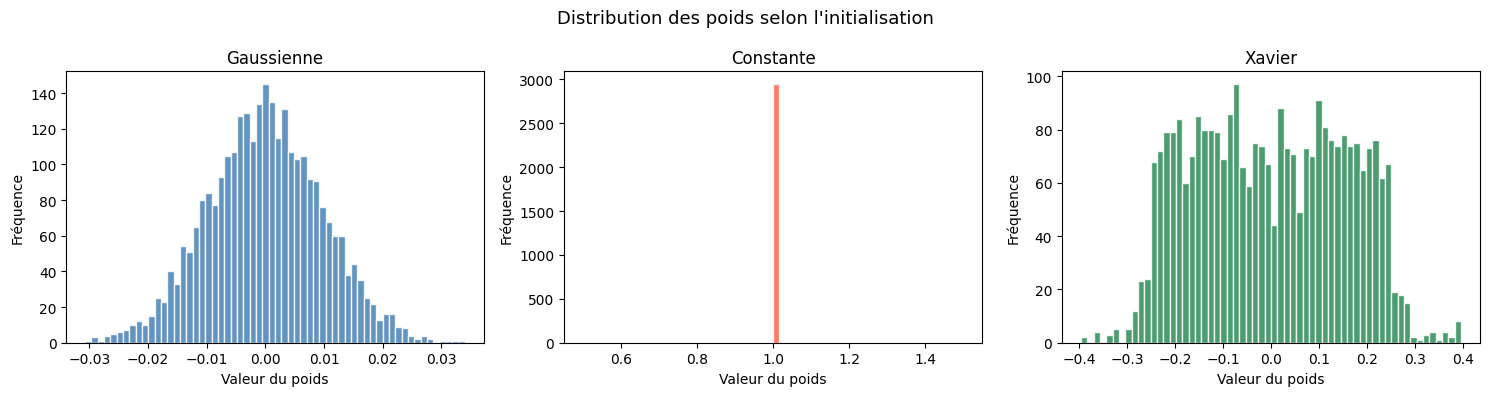

 Initialisation Xavier appliquée.


In [9]:
# ================================================================
# LES 3 INITIALISATIONS
# ================================================================
def init_gaussienne(module):
    if isinstance(module, nn.Linear):
        nn.init.normal_(module.weight, mean=0.0, std=0.01)
        nn.init.zeros_(module.bias)

def init_constante(module):
    if isinstance(module, nn.Linear):
        nn.init.constant_(module.weight, 1.0)
        nn.init.zeros_(module.bias)

def init_xavier(module):
    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        nn.init.zeros_(module.bias)


# Visualisation des distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
configs = [
    ('Gaussienne', init_gaussienne, 'steelblue'),
    ('Constante',  init_constante,  'tomato'),
    ('Xavier',     init_xavier,     'seagreen')
]
for ax, (titre, fn, color) in zip(axes, configs):
    m = MLP(11, [64, 32], 6)
    m.apply(fn)
    weights = torch.cat([p.data.flatten() for name, p in m.named_parameters() if 'weight' in name])
    ax.hist(weights.numpy(), bins=60, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(titre); ax.set_xlabel('Valeur du poids'); ax.set_ylabel('Fréquence')
plt.suptitle('Distribution des poids selon l\'initialisation', fontsize=13)
plt.tight_layout(); plt.show()

model_custom.apply(init_xavier)
print(' Initialisation Xavier appliquée.')

---
##  Étape I.6 — Vérification de cohérence device

In [10]:
# ================================================================
# VÉRIFICATION DEVICE
# ================================================================
model_device = next(model_custom.parameters()).device
sample_X, _ = next(iter(train_loader))
sample_X    = sample_X.to(device)

print('=== Vérification device ===')
print(f'  Device modèle  : {model_device}')
print(f'  Device données : {sample_X.device}')

if model_device == sample_X.device:
    print('   Cohérence OK')
else:
    print('   Incohérence — appeler .to(device) sur modèle ET données')

model_custom.eval()
with torch.no_grad():
    out = model_custom(sample_X)
print(f'   Forward pass OK — sortie shape : {out.shape}')

=== Vérification device ===
  Device modèle  : cpu
  Device données : cpu
   Cohérence OK
   Forward pass OK — sortie shape : torch.Size([32, 6])


---
##  Étape I.7 — Test de 5 architectures → sélection du Best Model

On teste 5 architectures MLP de complexité croissante :

| Architecture | Couches cachées |
|---|---|
| MLP 1 | `[32]` |
| MLP 2 | `[64, 32]` |
| MLP 3 | `[128, 64, 32]` |
| MLP 4 | `[256, 128, 64]` |
| MLP 5 | `[512, 256, 128, 64]` |

In [11]:
# ================================================================
# FONCTIONS D'ENTRAÎNEMENT ET D'ÉVALUATION
# ================================================================
def evaluate_accuracy(model, dataloader, device):
    """Calcule l'accuracy sur un DataLoader"""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            _, predicted = torch.max(model(X_batch), 1)
            total   += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    return 100.0 * correct / total


def train_mlp(model, train_loader, val_loader, device, lr=0.001, epochs=100):
    """Entraîne un MLP et retourne les courbes + meilleur state_dict"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, train_accs, val_accs = [], [], []
    best_val_acc, best_state = 0.0, None

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss    = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted  = torch.max(outputs, 1)
            total        += y_batch.size(0)
            correct      += (predicted == y_batch).sum().item()

        t_loss = running_loss / len(train_loader)
        t_acc  = 100.0 * correct / total
        v_acc  = evaluate_accuracy(model, val_loader, device)
        train_losses.append(t_loss)
        train_accs.append(t_acc)
        val_accs.append(v_acc)

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 20 == 0:
            print(f'  Epoch [{epoch+1}/{epochs}]  Loss={t_loss:.4f}  Train={t_acc:.1f}%  Val={v_acc:.1f}%')

    return train_losses, train_accs, val_accs, best_state, best_val_acc

In [12]:
# ================================================================
# TEST DES 5 ARCHITECTURES
# ================================================================
architectures = [
    ('MLP 1 — [32]',              [32]),
    ('MLP 2 — [64, 32]',          [64, 32]),
    ('MLP 3 — [128, 64, 32]',     [128, 64, 32]),
    ('MLP 4 — [256, 128, 64]',    [256, 128, 64]),
    ('MLP 5 — [512, 256, 128, 64]',[512, 256, 128, 64])
]

resultats = {}

for nom, hidden in architectures:
    print(f'\n=== {nom} ===')
    m = MLP(input_size=11, hidden_sizes=hidden, output_size=6).to(device)
    m.apply(init_xavier)
    n_params = sum(p.numel() for p in m.parameters())
    print(f'  Paramètres : {n_params}')

    losses, t_accs, v_accs, best_state, best_val = train_mlp(
        m, train_loader, val_loader, device, lr=0.001, epochs=100
    )

    # Test accuracy
    m.load_state_dict(best_state)
    test_acc = evaluate_accuracy(m, test_loader, device)
    print(f'  ✅ Test Accuracy : {test_acc:.2f}%')

    resultats[nom] = {
        'hidden'    : hidden,
        'params'    : n_params,
        'val_accs'  : v_accs,
        'losses'    : losses,
        'best_val'  : best_val,
        'test_acc'  : test_acc,
        'best_state': best_state
    }


=== MLP 1 — [32] ===
  Paramètres : 582
  Epoch [20/100]  Loss=0.9099  Train=63.1%  Val=58.8%
  Epoch [40/100]  Loss=0.8706  Train=63.9%  Val=57.8%
  Epoch [60/100]  Loss=0.8245  Train=64.8%  Val=57.4%
  Epoch [80/100]  Loss=0.8202  Train=65.5%  Val=59.3%
  Epoch [100/100]  Loss=0.7950  Train=66.2%  Val=59.3%
  ✅ Test Accuracy : 62.50%

=== MLP 2 — [64, 32] ===
  Paramètres : 3046
  Epoch [20/100]  Loss=0.8258  Train=64.6%  Val=59.3%
  Epoch [40/100]  Loss=0.7262  Train=68.4%  Val=59.8%
  Epoch [60/100]  Loss=0.6683  Train=71.2%  Val=60.3%
  Epoch [80/100]  Loss=0.5928  Train=76.1%  Val=61.8%
  Epoch [100/100]  Loss=0.5320  Train=78.9%  Val=61.8%
  ✅ Test Accuracy : 67.50%

=== MLP 3 — [128, 64, 32] ===
  Paramètres : 12070
  Epoch [20/100]  Loss=0.7234  Train=70.0%  Val=60.8%
  Epoch [40/100]  Loss=0.5569  Train=79.0%  Val=60.3%
  Epoch [60/100]  Loss=0.3635  Train=86.8%  Val=58.8%
  Epoch [80/100]  Loss=0.2463  Train=91.3%  Val=60.3%
  Epoch [100/100]  Loss=0.1443  Train=96.5%  Val=

=== Tableau comparatif des 5 architectures ===
Architecture                   Paramètres     Val Acc      Test Acc
----------------------------------------------------------------------
MLP 1 — [32]                   582            60.29%       62.50%
MLP 2 — [64, 32]               3046           63.24%       67.50%
MLP 3 — [128, 64, 32]          12070          62.75%       63.33%
MLP 4 — [256, 128, 64]         44614          66.67%       68.75%
MLP 5 — [512, 256, 128, 64]    179014         65.69%       63.33%


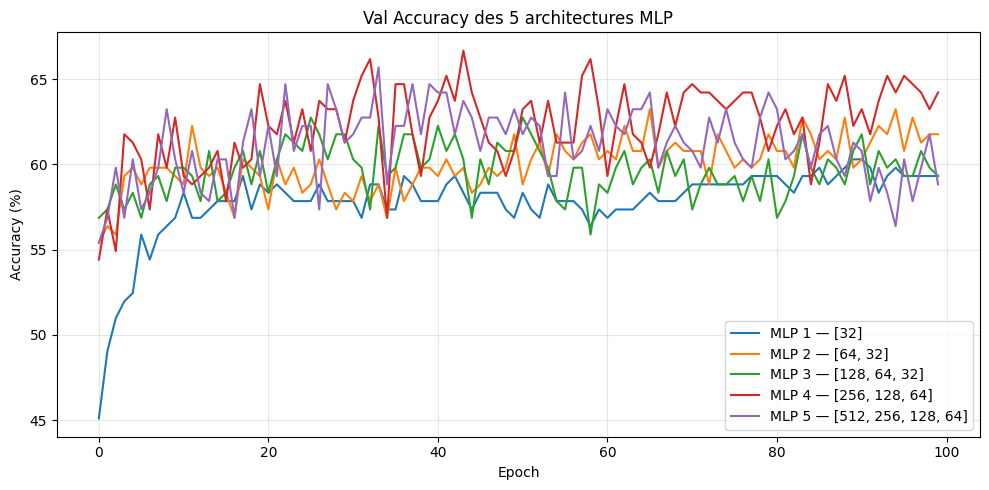

In [13]:
# ================================================================
# TABLEAU COMPARATIF DES 5 ARCHITECTURES
# ================================================================
print('=== Tableau comparatif des 5 architectures ===')
print(f'{"Architecture":<30} {"Paramètres":<14} {"Val Acc":<12} {"Test Acc"}')
print('-' * 70)
for nom, res in resultats.items():
    print(f'{nom:<30} {res["params"]:<14} {res["best_val"]:.2f}%{"":6} {res["test_acc"]:.2f}%')

# Courbes val accuracy des 5 architectures
plt.figure(figsize=(10, 5))
for nom, res in resultats.items():
    plt.plot(res['val_accs'], label=nom)
plt.title('Val Accuracy des 5 architectures MLP')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [14]:
# ================================================================
# SÉLECTION DU BEST MODEL
# ================================================================

# Le best model est celui avec la meilleure test accuracy
best_nom = max(resultats, key=lambda k: resultats[k]['test_acc'])
best_res = resultats[best_nom]

print(f' Best Model : {best_nom}')
print(f'   Test Accuracy : {best_res["test_acc"]:.2f}%')
print(f'   Val Accuracy  : {best_res["best_val"]:.2f}%')
print(f'   Paramètres    : {best_res["params"]}')

# Sauvegarder le best model
torch.save(best_res['best_state'], 'meilleur_mlp.pth')
print('\n Best model sauvegardé dans meilleur_mlp.pth')

# Recharger le best model
model_reloaded = MLP(input_size=11, hidden_sizes=best_res['hidden'], output_size=6).to(device)
model_reloaded.load_state_dict(torch.load('meilleur_mlp.pth', map_location=device))
model_reloaded.eval()
print(' Best model rechargé avec succès.')

 Best Model : MLP 4 — [256, 128, 64]
   Test Accuracy : 68.75%
   Val Accuracy  : 66.67%
   Paramètres    : 44614

 Best model sauvegardé dans meilleur_mlp.pth
 Best model rechargé avec succès.


---
##  Étape I.8 — Évaluation complète du Best Model

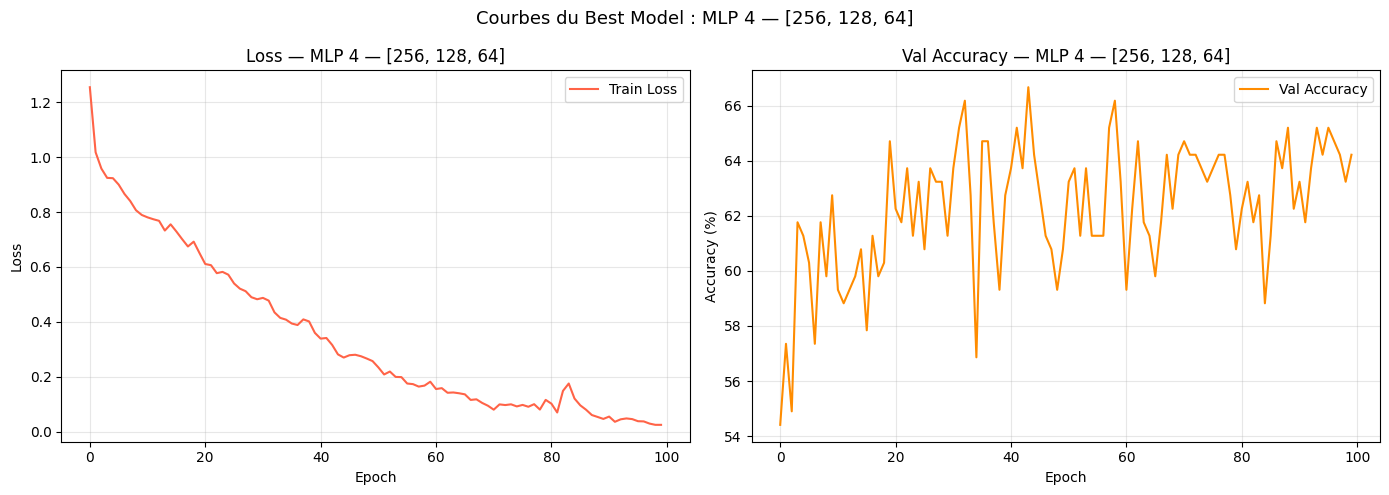

In [15]:
# ================================================================
# COURBES D'APPRENTISSAGE DU BEST MODEL
# ================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(best_res['losses'],   color='tomato',     label='Train Loss')
ax1.set_title(f'Loss — {best_nom}')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(best_res['val_accs'], color='darkorange', label='Val Accuracy')
ax2.set_title(f'Val Accuracy — {best_nom}')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle(f'Courbes du Best Model : {best_nom}', fontsize=13)
plt.tight_layout(); plt.show()

c:\Users\andal\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\andal\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\andal\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

=== Métriques du Best Model (MLP 4 — [256, 128, 64]) ===
  Accuracy  : 68.75%
  Precision : 34.22%  → parmi les prédictions positives, combien sont correctes ?
  Recall    : 35.08%  → parmi les vrais positifs, combien sont détectés ?
  F1-score  : 34.64%  → moyenne harmonique precision/recall

=== Rapport complet par classe ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         8
           5       0.75      0.79      0.77       102
           6       0.67      0.68      0.67        96
           7       0.63      0.63      0.63        30
           8       0.00      0.00      0.00         3

    accuracy                           0.69       240
   macro avg       0.34      0.35      0.35       240
weighted avg       0.67      0.69      0.68       240



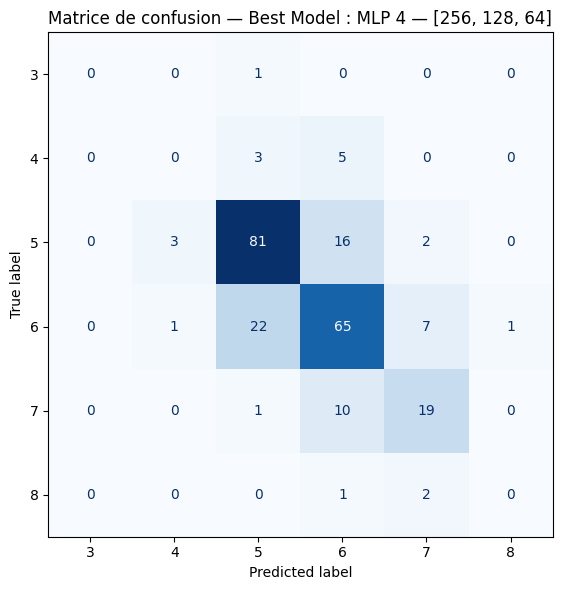

In [16]:
# ================================================================
# MÉTRIQUES COMPLÈTES : accuracy, precision, recall, F1
# + matrice de confusion
# ================================================================
all_labels, all_preds = [], []
model_reloaded.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs  = model_reloaded(X_batch.to(device))
        _, preds = torch.max(outputs, 1)
        all_labels.extend(y_batch.numpy())
        all_preds.extend(preds.cpu().numpy())

acc  = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='macro')
rec  = recall_score(all_labels, all_preds, average='macro')
f1   = f1_score(all_labels, all_preds, average='macro')

print(f'=== Métriques du Best Model ({best_nom}) ===')
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {prec*100:.2f}%  → parmi les prédictions positives, combien sont correctes ?')
print(f'  Recall    : {rec*100:.2f}%  → parmi les vrais positifs, combien sont détectés ?')
print(f'  F1-score  : {f1*100:.2f}%  → moyenne harmonique precision/recall')

print('\n=== Rapport complet par classe ===')
print(classification_report(all_labels, all_preds,
      target_names=[str(c) for c in le.classes_]))

# Matrice de confusion
cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=[str(c) for c in le.classes_])
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title(f'Matrice de confusion — Best Model : {best_nom}')
plt.tight_layout(); plt.show()


--- Init : Gaussienne ---
  Epoch [20/100]  Loss=0.8910  Train=61.1%  Val=59.8%
  Epoch [40/100]  Loss=0.8343  Train=63.8%  Val=60.8%
  Epoch [60/100]  Loss=0.7779  Train=67.1%  Val=62.3%
  Epoch [80/100]  Loss=0.6718  Train=71.5%  Val=62.3%
  Epoch [100/100]  Loss=0.5400  Train=77.1%  Val=63.7%

--- Init : Constante ---
  Epoch [20/100]  Loss=356.3684  Train=39.6%  Val=42.6%
  Epoch [40/100]  Loss=52.4581  Train=39.6%  Val=39.7%
  Epoch [60/100]  Loss=18.0774  Train=39.5%  Val=28.4%
  Epoch [80/100]  Loss=9.2113  Train=39.7%  Val=40.7%
  Epoch [100/100]  Loss=5.5568  Train=39.3%  Val=39.7%

--- Init : Xavier ---
  Epoch [20/100]  Loss=0.6589  Train=73.2%  Val=62.3%
  Epoch [40/100]  Loss=0.3541  Train=87.3%  Val=60.8%
  Epoch [60/100]  Loss=0.1424  Train=96.2%  Val=63.2%
  Epoch [80/100]  Loss=0.0824  Train=98.0%  Val=62.3%
  Epoch [100/100]  Loss=0.0209  Train=99.6%  Val=61.8%


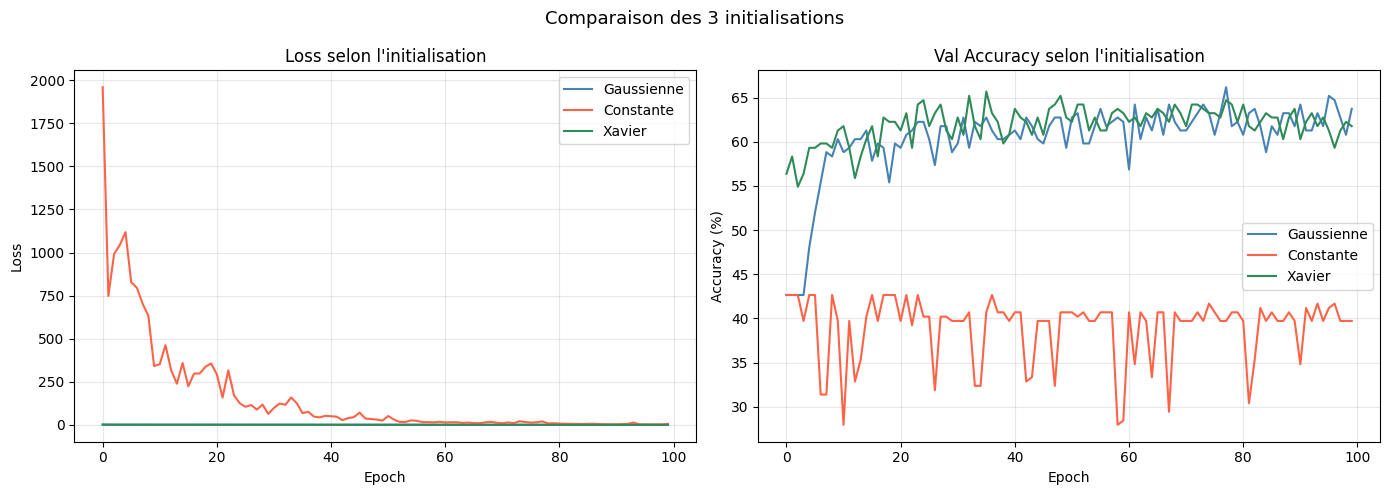


=== Val Accuracy finale ===
  Gaussienne   : 63.73%
  Constante    : 39.71%
  Xavier       : 61.76%


In [17]:
# ================================================================
# COMPARAISON DES 3 INITIALISATIONS sur le Best Model
# ================================================================
resultats_init = {}
configs = [
    ('Gaussienne', init_gaussienne),
    ('Constante',  init_constante),
    ('Xavier',     init_xavier)
]

for nom, fn in configs:
    print(f'\n--- Init : {nom} ---')
    m = MLP(input_size=11, hidden_sizes=best_res['hidden'], output_size=6).to(device)
    m.apply(fn)
    losses, t_accs, v_accs, _, _ = train_mlp(
        m, train_loader, val_loader, device, lr=0.001, epochs=100
    )
    resultats_init[nom] = {'losses': losses, 'val_accs': v_accs}

couleurs = {'Gaussienne': 'steelblue', 'Constante': 'tomato', 'Xavier': 'seagreen'}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for nom, res in resultats_init.items():
    ax1.plot(res['losses'],   label=nom, color=couleurs[nom])
    ax2.plot(res['val_accs'], label=nom, color=couleurs[nom])

ax1.set_title('Loss selon l\'initialisation')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.set_title('Val Accuracy selon l\'initialisation')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Comparaison des 3 initialisations', fontsize=13)
plt.tight_layout(); plt.show()

print('\n=== Val Accuracy finale ===')
for nom, res in resultats_init.items():
    print(f'  {nom:12s} : {res["val_accs"][-1]:.2f}%')